This is a complementary notebook for tutorial lectures on introduction to PyTorch for [STAT8056](http://users.stat.umn.edu/~xshen/stat8056.htm), 2026 Spring. To access the slides for this tutorial, please visit [https://github.com/shakayoyo/Pytorch_intro/](https://github.com/shakayoyo/Pytorch_intro/).

In [1]:
# In Colab, PyTorch is usually pre-installed.
# Use this command if you need to install or upgrade it.
!pip install torch torchvision torchaudio

In [1]:
# basic torch modules, classes and functions
import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

# image datasets and pre-processing
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms

# other utils libraries
import time
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Print the current version of the PyTorch library
print(f"PyTorch version: {torch.__version__}")

# Print the current version of the Torchvision library
print(f"Torchvision version: {torchvision.__version__}")

PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128


In [1]:
! nvidia-smi

Sat Mar 14 20:44:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Tensor

A **Tensor** is a fundamental data structure in PyTorch, similar to NumPy arrays but with the added capability to run on GPUs for accelerated computing. Tensors are used to encode inputs, outputs, and the parameters of a model.

### Tensor creation
You can create Tensors from Python lists, NumPy arrays, or by initializing them with specific values like ones or random numbers.

In [5]:
# Create a tensor from a Python list
data = [[1, 2],[3, 4]]
x_data = torch.tensor(data)
print("Tensor from Python list:\n", x_data)

# Create a tensor from a NumPy array
np_array = np.array(data)
x_np = torch.tensor(np_array)
print("\nTensor from NumPy array:\n", x_np)

# Create a tensor of ones
x_ones = torch.ones(5, 3, dtype=torch.float32)
print("\nTensor of ones:\n", x_ones)

# Create a tensor of random values
x_rand = torch.rand(5, 3)
print("\nTensor of random values:\n", x_rand)

# Get tensor properties
print("\nShape of x_data:", x_data.shape)
print("Datatype of x_data:", x_data.dtype)
print("Device x_data is stored on:", x_data.device)


Tensor from Python list:
 tensor([[1, 2],
        [3, 4]])

Tensor from NumPy array:
 tensor([[1, 2],
        [3, 4]])

Tensor of ones:
 tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])

Tensor of random values:
 tensor([[0.1177, 0.1570, 0.7063],
        [0.2510, 0.8816, 0.5737],
        [0.5501, 0.0888, 0.0798],
        [0.4934, 0.3758, 0.4246],
        [0.8513, 0.7490, 0.8070]])

Shape of x_data: torch.Size([2, 2])
Datatype of x_data: torch.int64
Device x_data is stored on: cpu


### Tensor indexing

Tensor indexing is a powerful feature in PyTorch that allows you to access and modify specific elements or sub-tensors within a larger tensor. It works similarly to NumPy array indexing and supports various methods:

*   **Single Element Indexing:** Access a single value using row and column indices (e.g., `tensor[row, col]`).
*   **Slicing:** Extract sub-tensors by specifying ranges for rows and columns (e.g., `tensor[start_row:end_row, start_col:end_col]`).
*   **Advanced Indexing:** Use lists or other tensors as indices to select non-contiguous elements or to reorder dimensions.
*   **Boolean Indexing:** Select elements based on a condition, returning a new tensor containing only the elements that satisfy the condition.

In [4]:
x = torch.tensor([[1, 2, 3],
                  [4, 5, 6],
                  [7, 8, 9]])

print("Original tensor:\n", x)

# Accessing a single element (row 0, column 1)
print("\nElement at (0, 1):", x[0, 1])

# Accessing a row (row 1)
print("\nRow 1:", x[1])

# Accessing a column (column 2)
print("\nColumn 2:", x[:, 2])

# Accessing a slice (first two rows, all columns)
print("\nFirst two rows:\n", x[:2, :])

# Accessing elements using lists/tensors of indices
# For example, elements at (0,0), (1,1), (2,2)
indices = torch.tensor([0, 1, 2])
print("\nDiagonal elements:", x[indices, indices])

# Boolean indexing (elements greater than 5)
print("\nElements greater than 5:", x[x > 5])


Original tensor:
 tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])

Element at (0, 1): tensor(2)

Row 1: tensor([4, 5, 6])

Column 2: tensor([3, 6, 9])

First two rows:
 tensor([[1, 2, 3],
        [4, 5, 6]])

Diagonal elements: tensor([1, 5, 9])

Elements greater than 5: tensor([6, 7, 8, 9])


### Tensor operation

PyTorch tensors support a wide array of operations that can be categorized as follows:

*   **Arithmetic Operations:** Element-wise addition, subtraction, multiplication, and division (e.g., `a + b`, `a - b`, `a * b`, `a / b`).
*   **Matrix Operations:** Matrix multiplication (e.g., `a @ b` or `torch.matmul(a, b)`), dot products, cross products.
*   **Reduction Operations:** Operations that reduce the number of dimensions, such as summing all elements (`torch.sum()`), finding the mean (`torch.mean()`), or finding the max/min along a dimension (`torch.max()`, `torch.min()`).
*   **Broadcasting:** PyTorch automatically broadcasts tensors with different shapes when they are compatible, making operations on tensors of varying sizes intuitive.
*   **In-place Operations:** Many operations have an in-place version (denoted by a trailing underscore, e.g., `tensor.add_(other_tensor)`) which modifies the tensor directly without creating a new one.
*   **Reshaping Operations:** Functions like `view()`, `reshape()`, `squeeze()`, and `unsqueeze()` allow you to change the shape of a tensor without changing its data.

In [14]:
# Define two tensors
x = torch.tensor([[1, 2], [3, 4]])
y = torch.tensor([[5, 6], [7, 8]])

print("x:\n", x)
print("y:\n", y)

# Tensor addition
print("\nAddition (x + y):\n", x + y)

# Tensor multiplication (element-wise)
print("\nElement-wise Multiplication (x * y):\n", x * y)

# Matrix multiplication (using @ operator)
print("\nMatrix Multiplication (x @ y):\n", x @ y)

# Matrix multiplication (using torch.matmul)
print("\nMatrix Multiplication (torch.matmul(x, y)):\n", torch.matmul(x, y))

# In-place operations (e.g., add_)
x.add_(y)
print("\nIn-place Addition (x.add_(y)):\n", x)


x:
 tensor([[1, 2],
        [3, 4]])
y:
 tensor([[5, 6],
        [7, 8]])

Addition (x + y):
 tensor([[ 6,  8],
        [10, 12]])

Element-wise Multiplication (x * y):
 tensor([[ 5, 12],
        [21, 32]])

Matrix Multiplication (x @ y):
 tensor([[19, 22],
        [43, 50]])

Matrix Multiplication (torch.matmul(x, y)):
 tensor([[19, 22],
        [43, 50]])

In-place Addition (x.add_(y)):
 tensor([[ 6,  8],
        [10, 12]])


In [6]:
# Reduction Operations
x = torch.tensor([[1, 2, 3], [4, 5, 6]])

print("Original tensor for reduction:\n", x)
print("Tensor shape:", x.shape)
print("\nSum of all elements:", torch.sum(x))
print("Mean of all elements:", torch.mean(x.float())) # mean requires float
print("Max along dimension 0:", torch.max(x, dim=0))
print("Min along dimension 1:", torch.min(x, dim=1))


Original tensor for reduction:
 tensor([[1, 2, 3],
        [4, 5, 6]])
Tensor shape: torch.Size([2, 3])

Sum of all elements: tensor(21)
Mean of all elements: tensor(3.5000)
Max along dimension 0: torch.return_types.max(
values=tensor([4, 5, 6]),
indices=tensor([1, 1, 1]))
Min along dimension 1: torch.return_types.min(
values=tensor([1, 4]),
indices=tensor([0, 0]))


In [12]:
# Broadcasting
x = torch.tensor([[1, 2], [3, 4]])
y = torch.tensor([10, 20]) # This tensor will be broadcast
print("Tensor x:\n", x)
print("Tensor y:\n", y)
print("\nBroadcasting x + y:\n", x + y)


Tensor x:
 tensor([[1, 2],
        [3, 4]])
Tensor y:
 tensor([10, 20])

Broadcasting x + y:
 tensor([[11, 22],
        [13, 24]])


In [4]:
# Reshaping Operations
x = torch.randn(2, 3, 4)
print("Original tensor x:\n", x, "\nShape:", x.shape)

# Reshape using view()
y_view = x.view(2, 12)
print("\nTensor after x.view(2, 12):\n", y_view, "\nShape:", y_view.shape)

# Reshape using reshape()
y_reshape = x.reshape(8, 3)
print("\nTensor after x.reshape(8, 3):\n", y_reshape, "\nShape:", y_reshape.shape)

# Squeeze and Unsqueeze (remove/add dimensions of size 1)
z = torch.zeros(1, 5, 1)
print("\nOriginal tensor z:\n", z, "\nShape:", z.shape)

z_squeezed = z.squeeze()
print("\nTensor after z.squeeze():\n", z_squeezed, "\nShape:", z_squeezed.shape)

z_unsqueezed = z_squeezed.unsqueeze(0)
print("\nTensor after z_squeezed.unsqueeze(0):\n", z_unsqueezed, "\nShape:", z_unsqueezed.shape)


Original tensor x:
 tensor([[[-0.4803,  1.1815,  0.1641,  0.2615],
         [-0.1261, -0.4722,  0.5832, -0.9014],
         [ 0.8996, -0.5744,  0.4243,  0.5791]],

        [[-1.1329,  0.0800,  0.1793,  0.3095],
         [ 0.5461, -0.8766,  0.4527,  0.2796],
         [-0.3750,  0.5792, -0.2553, -1.5762]]]) 
Shape: torch.Size([2, 3, 4])

Tensor after x.view(2, 12):
 tensor([[-0.4803,  1.1815,  0.1641,  0.2615, -0.1261, -0.4722,  0.5832, -0.9014,
          0.8996, -0.5744,  0.4243,  0.5791],
        [-1.1329,  0.0800,  0.1793,  0.3095,  0.5461, -0.8766,  0.4527,  0.2796,
         -0.3750,  0.5792, -0.2553, -1.5762]]) 
Shape: torch.Size([2, 12])

Tensor after x.reshape(8, 3):
 tensor([[-0.4803,  1.1815,  0.1641],
        [ 0.2615, -0.1261, -0.4722],
        [ 0.5832, -0.9014,  0.8996],
        [-0.5744,  0.4243,  0.5791],
        [-1.1329,  0.0800,  0.1793],
        [ 0.3095,  0.5461, -0.8766],
        [ 0.4527,  0.2796, -0.3750],
        [ 0.5792, -0.2553, -1.5762]]) 
Shape: torch.Size([8,

## Create tensors with gradient tracing

In [17]:
t = torch.tensor(3.0, requires_grad = True)
print("Tensor t:", t)

Tensor t: tensor(3., requires_grad=True)


## Calculate and access the gradient

In [7]:
# create tensors, and enable gradient tracing
c = torch.tensor(1.)
t = torch.tensor(3., requires_grad = True)
print("Tensor c:", c)
print("Tensor t:", t)

# do some calculation
s = t**2
f = 3 * s + c

# calculate the gradient of f w.r.t. t
f.backward()

# access the gradient
print("Gradient df/dt:", t.grad)

Tensor c: tensor(1.)
Tensor t: tensor(3., requires_grad=True)
Gradient df/dt: tensor(18.)


In [5]:
# Example demonstrating .detach(), torch.no_grad()

# 1. Using .detach()
print("--- Demonstrating .detach() ---")
a = torch.tensor(2.0, requires_grad=True)
b = a * 3
# Detach 'b' to create a new tensor 'c' that does not track gradients
c = b.detach()
d = c * 2

print(f"Tensor a: {a}, requires_grad={a.requires_grad}")
print(f"Tensor b (a*3): {b}, requires_grad={b.requires_grad}")
print(f"Tensor c (b.detach()): {c}, requires_grad={c.requires_grad}")
print(f"Tensor d (c*2): {d}, requires_grad={d.requires_grad}")

try:
    d.backward() # This will fail because 'd' does not have requires_grad=True
except RuntimeError as e:
    print(f"\nError trying to backward through 'd': {e}")
print("Note: Gradients cannot flow through 'c' to 'b' and 'a' because 'c' was detached.")

# To get gradients for 'a' from 'b', we need to backward through 'b'
# First, zero out any existing gradients for 'a' (if previous backward was successful elsewhere)
if a.grad is not None: a.grad.zero_()
b.backward()
print(f"Gradient of b w.r.t a: {a.grad}")

# 2. Using torch.no_grad()
print("\n--- Demonstrating torch.no_grad() ---")
x = torch.tensor(5.0, requires_grad=True)
y = x * 2

with torch.no_grad():
    z = y * 3 # Operations inside no_grad() block will not track gradients

print(f"Tensor x: {x}, requires_grad={x.requires_grad}")
print(f"Tensor y (x*2): {y}, requires_grad={y.requires_grad}")
print(f"Tensor z (y*3 inside no_grad): {z}, requires_grad={z.requires_grad}")

try:
    z.backward() # This will fail as 'z' does not track gradients
except RuntimeError as e:
    print(f"\nError trying to backward through 'z': {e}")
print("Note: 'z' does not have requires_grad=True because it was created inside torch.no_grad().")


--- Demonstrating .detach() ---
Tensor a: 2.0, requires_grad=True
Tensor b (a*3): 6.0, requires_grad=True
Tensor c (b.detach()): 6.0, requires_grad=False
Tensor d (c*2): 12.0, requires_grad=False

Error trying to backward through 'd': element 0 of tensors does not require grad and does not have a grad_fn
Note: Gradients cannot flow through 'c' to 'b' and 'a' because 'c' was detached.
Gradient of b w.r.t a: 3.0

--- Demonstrating torch.no_grad() ---
Tensor x: 5.0, requires_grad=True
Tensor y (x*2): 10.0, requires_grad=True
Tensor z (y*3 inside no_grad): 30.0, requires_grad=False

Error trying to backward through 'z': element 0 of tensors does not require grad and does not have a grad_fn
Note: 'z' does not have requires_grad=True because it was created inside torch.no_grad().


## Common MISTAKES regarding gradient and computation graph

### Call `.backward` when there is no graph (or the graph has been destroyed)

In [8]:
t = torch.tensor(3., requires_grad = True)
s = t**2
s.backward() # graph is destroyed

s.backward() # error!

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

### Call `.grad` on non-leaf nodes

In [4]:
t = torch.tensor(3., requires_grad = True) # the leaf node
s = t**2 # the intermediate node

# uncomment this to retain gradient of the non-leaf node s
# s.retain_grad()

f = 3 * s + 1 # the objective
f.backward()

s.grad # warning and no result

/tmp/ipykernel_13789/1486570255.py:10: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:492.)
  s.grad # warning and no result


### Gradient accumulation

In [10]:
# first back propagation
t = torch.tensor(3., requires_grad = True)
s = t**2
s.backward()
print("Gradient ds/dt:", t.grad)

# second back propagation
f = 5 * t + 1
f.backward()
print("Gradient df/dt (without emptying t.grad):", t.grad)

Gradient ds/dt: tensor(6.)
Gradient df/dt (without emptying t.grad): tensor(11.)


In [11]:
t.grad.zero_() # zero out the gradient
f = 5 * t + 1
f.backward()
print("Gradient df/dt (after emptying t.grad):", t.grad)

Gradient df/dt (after emptying t.grad): tensor(5.)


# Tensor manipulation on GPU

To use GPU of Google Colab, go to `Runtime|Change runtime type|Hardware accelerator|GPU|Save`.

## Check GPU availability

In [23]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


## Matrix multiplication on CPU versus GPU

In [24]:
d = 3000

# C = A B with numpy on CPU
A = np.random.rand(d, d)
B = np.random.rand(d, d)
begin = time.time()
C = A.dot(B)
print(f"CPU time (numpy): {time.time() - begin} s")

# C = A B with torch on CPU
A_t_cpu = torch.tensor(A)
B_t_cpu = torch.tensor(B)
begin = time.time()
C = torch.mm(A_t_cpu, B_t_cpu)
print(f"CPU time (torch): {time.time() - begin} s")

# C = A B with torch on GPU
# make sure GPU is available
# it takes some time to initialize using GPU for the first time, so run this cell for a second time
A_t_gpu = torch.tensor(A).cuda()
B_t_gpu = torch.tensor(B).cuda()
begin = time.time()
C = torch.mm(A_t_gpu, B_t_gpu)
print(f"GPU time (torch): {time.time() - begin} s")

CPU time (numpy): 1.0767033100128174 s
CPU time (torch): 1.032503604888916 s
GPU time (torch): 0.11493325233459473 s


## Transfer time from CPU to GPU

In [25]:
d = 3000
begin = time.time()
A = torch.rand((d, d)).cuda()
B = torch.rand((d, d)).cuda()
print(f"Time from CPU to GPU: {time.time() - begin} s")
begin = time.time()
C = torch.mm(A, B)
print(f"GPU time (torch): {time.time() - begin} s")

Time from CPU to GPU: 0.15135836601257324 s
GPU time (torch): 0.035066843032836914 s


# Linear regression in PyTorch

## Linear regression --- the naive approach

In [27]:
n = 2000
x = torch.rand(n)

# create dataset with true model
a0 = 2
b0 = 1
y = a0 * x + b0

# set up optimization parameter of SGD
a = torch.rand(1, requires_grad = True)
b = torch.rand(1, requires_grad = True)
nepochs = 10
batch_size = 200
lr = 0.5

In [28]:
for epoch in range(nepochs):
  for batch in range(round(n / batch_size)):
    start = batch * batch_size
    end = start + batch_size
    # perform update on a batch
    x_batch = x[start:end]
    y_batch = y[start:end]

    # build computation graph
    y_hat = a * x_batch + b
    myloss = torch.mean((y_batch - y_hat)**2)

    # gradient calculation
    myloss.backward()

    # SGD update
    with torch.no_grad():
      a -= lr * a.grad
      b -= lr * b.grad

    # avoid gradient accumulation
    a.grad.zero_()
    b.grad.zero_()

  print(f"Epoch: {epoch + 1} / {nepochs}")
  print(f"MSE: {myloss: .2e}; a: {a.item():.4f}; b: {b.item():.4f}")


Epoch: 1 / 10
MSE:  1.31e-02; a: 1.6337; b: 1.2124
Epoch: 2 / 10
MSE:  3.45e-03; a: 1.8120; b: 1.1090
Epoch: 3 / 10
MSE:  9.09e-04; a: 1.9035; b: 1.0560
Epoch: 4 / 10
MSE:  2.40e-04; a: 1.9505; b: 1.0287
Epoch: 5 / 10
MSE:  6.31e-05; a: 1.9746; b: 1.0147
Epoch: 6 / 10
MSE:  1.66e-05; a: 1.9869; b: 1.0076
Epoch: 7 / 10
MSE:  4.38e-06; a: 1.9933; b: 1.0039
Epoch: 8 / 10
MSE:  1.15e-06; a: 1.9966; b: 1.0020
Epoch: 9 / 10
MSE:  3.04e-07; a: 1.9982; b: 1.0010
Epoch: 10 / 10
MSE:  8.02e-08; a: 1.9991; b: 1.0005


## Linear regression --- the PyTorch way

In [44]:
class SimpleLinear(Dataset):
    def __init__(self, n, a, b, sigma = 0):
      self.n = n
      self.x = torch.rand(n, 1)
      self.y = a * self.x + b + sigma * torch.randn(n, 1)

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

# This is an example of defining a simple linear model using nn.Sequential.
# mymodel = nn.Sequential(nn.Linear(1, 1))

# Manually defined Linear Regression Model class
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(1, 1) # Input dimension 1, output dimension 1

    def forward(self, x):
        return self.linear(x)

# create a training model using the custom class
mymodel = LinearRegressionModel()

# prepare dataset and dataloaders
mydata = SimpleLinear(n = 2000, a = 2, b = 1)
mydataloader = DataLoader(mydata, batch_size = 200)

# set up optimization with SGD
criterion = nn.MSELoss()
optimizer = optim.SGD(mymodel.parameters(), lr = 0.5)


In [45]:
nepochs = 10
for epoch in range(nepochs):
  for x_batch, y_batch in mydataloader:
    # build computation graph
    yhat = mymodel(x_batch)
    myloss = criterion(y_batch, yhat)

    # optimization
    optimizer.zero_grad() # zero out gradient
    myloss.backward() # back propagation
    optimizer.step() # updata parameters

  a = mymodel.linear.weight.item()
  b = mymodel.linear.bias.item()
  #a = mymodel[0].weight.item()
  #b = mymodel[0].bias.item()
  print(f"Epoch: {epoch + 1} / {nepochs}")
  print(f"MSE: {myloss: .2e}; a: {a:.4f}; b: {b:.4f}")

Epoch: 1 / 10
MSE:  7.53e-02; a: 1.1121; b: 1.4864
Epoch: 2 / 10
MSE:  1.97e-02; a: 1.5459; b: 1.2488
Epoch: 3 / 10
MSE:  5.15e-03; a: 1.7678; b: 1.1272
Epoch: 4 / 10
MSE:  1.35e-03; a: 1.8812; b: 1.0651
Epoch: 5 / 10
MSE:  3.53e-04; a: 1.9393; b: 1.0333
Epoch: 6 / 10
MSE:  9.22e-05; a: 1.9689; b: 1.0170
Epoch: 7 / 10
MSE:  2.41e-05; a: 1.9841; b: 1.0087
Epoch: 8 / 10
MSE:  6.31e-06; a: 1.9919; b: 1.0045
Epoch: 9 / 10
MSE:  1.65e-06; a: 1.9958; b: 1.0023
Epoch: 10 / 10
MSE:  4.32e-07; a: 1.9979; b: 1.0012


# Regression with ReLU neural net

In [31]:
class SinData(Dataset):
    def __init__(self, n, p = 5, sigma = 0):
      self.n = n
      self.x = 2 * torch.rand(n, p) - 1
      self.x1 = self.x[:, :1]
      self.y = torch.sin(4 * self.x1) + sigma * torch.randn(n, 1)

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


# initialize a training model
train_model = nn.Sequential(
    nn.Linear(5, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 1)
)

# prepare TRAINING dataset and dataloaders
train_data = SinData(n = 200, sigma = 0.2)
train_loader = DataLoader(train_data, batch_size = 200) # simple GD
test_data = SinData(n = 200, sigma = 0.2)
test_loader = DataLoader(test_data, batch_size = 200) # simple GD

# set up optimization with SGD
criterion = nn.MSELoss()

# WITHOUT WEIGHT DECAY
optimizer = optim.Adam(train_model.parameters(), lr = 0.001)
# # WITH WEIGHT DECAY
# optimizer = optim.Adam(train_model.parameters(), lr = 0.001, weight_decay = 0.01)

In [32]:
nepochs = 3000
for epoch in range(nepochs):
  for x_batch, y_batch in train_loader:
    # build computation graph
    yhat = train_model(x_batch)
    myloss = criterion(y_batch, yhat)

    # optimizatin
    optimizer.zero_grad() # zero out gradient
    myloss.backward() # back propagation
    optimizer.step() # updata parameters

  if epoch % 300 == 299:
    # evalulate MSE on the WHOLE traning / testing dataset
    with torch.no_grad():
      # training MSE
      y_hat_train = train_model(train_data.x)
      myloss_train = criterion(y_hat_train, train_data.y)
      # testing MSE
      x_test, y_test = next(iter(test_loader))
      y_test_hat = train_model(x_test)
      myloss_test = criterion(y_test_hat, y_test)
    print(f"Epoch: {epoch + 1} / {nepochs}; MSE (training): {myloss_train: .2e}; MSE (testing): {myloss_test: .2e}")


Epoch: 300 / 3000; MSE (training):  6.55e-04; MSE (testing):  1.08e-01
Epoch: 600 / 3000; MSE (training):  5.18e-04; MSE (testing):  1.08e-01
Epoch: 900 / 3000; MSE (training):  2.33e-05; MSE (testing):  1.09e-01
Epoch: 1200 / 3000; MSE (training):  2.45e-05; MSE (testing):  1.08e-01
Epoch: 1500 / 3000; MSE (training):  3.05e-05; MSE (testing):  1.09e-01
Epoch: 1800 / 3000; MSE (training):  6.65e-07; MSE (testing):  1.09e-01
Epoch: 2100 / 3000; MSE (training):  2.66e-07; MSE (testing):  1.09e-01
Epoch: 2400 / 3000; MSE (training):  1.48e-07; MSE (testing):  1.09e-01
Epoch: 2700 / 3000; MSE (training):  1.24e-06; MSE (testing):  1.09e-01
Epoch: 3000 / 3000; MSE (training):  2.40e-06; MSE (testing):  1.09e-01


In [33]:
# fitted value
x1_train, y_train = train_data.x1, train_data.y
x1_test, y_test = test_data.x1, test_data.y
with torch.no_grad():
  y_train_hat = train_model(train_data.x)
  y_test_hat = train_model(test_data.x)

Text(0.5, 1.0, 'True data (n = 200)')

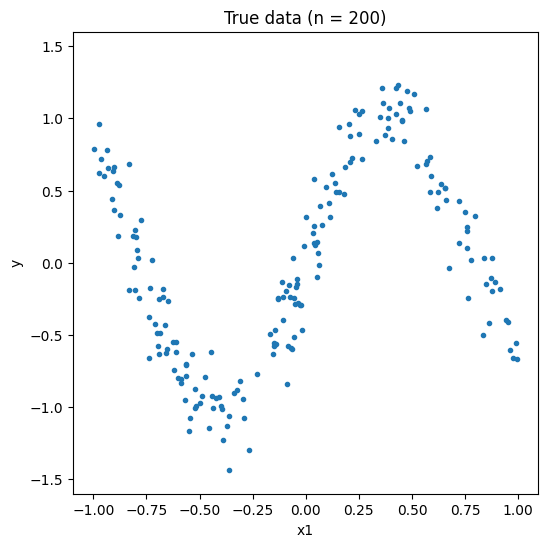

In [34]:
#@title Visualization of training data
plt.rcParams['figure.figsize'] = [6, 6]

plt.plot(x1_train, y_train, '.')
plt.ylim(-1.6, 1.6)
plt.xlabel("x1")
plt.ylabel("y")
plt.title("True data (n = 200)")

Text(0.5, 1.0, 'Fitted y versus true y')

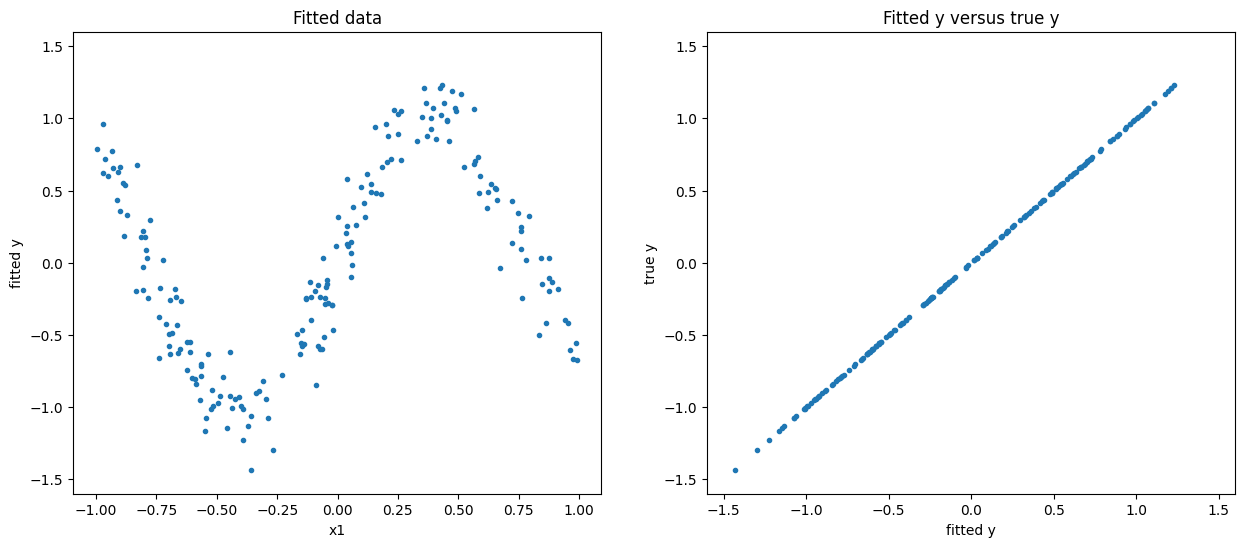

In [35]:
#@title Visulization of fitted values on training data
plt.rcParams['figure.figsize'] = [15, 6]

plt.subplot(1, 2, 1)
plt.plot(x1_train, y_train_hat, '.')
plt.ylim(-1.6, 1.6)
plt.xlabel("x1")
plt.ylabel("fitted y")
plt.title("Fitted data")

plt.subplot(1, 2, 2)
plt.plot(y_train, y_train_hat, '.')
plt.xlim(-1.6, 1.6)
plt.ylim(-1.6, 1.6)
plt.xlabel("fitted y")
plt.ylabel("true y")
plt.title("Fitted y versus true y")

Text(0.5, 1.0, 'Fitted y versus true y')

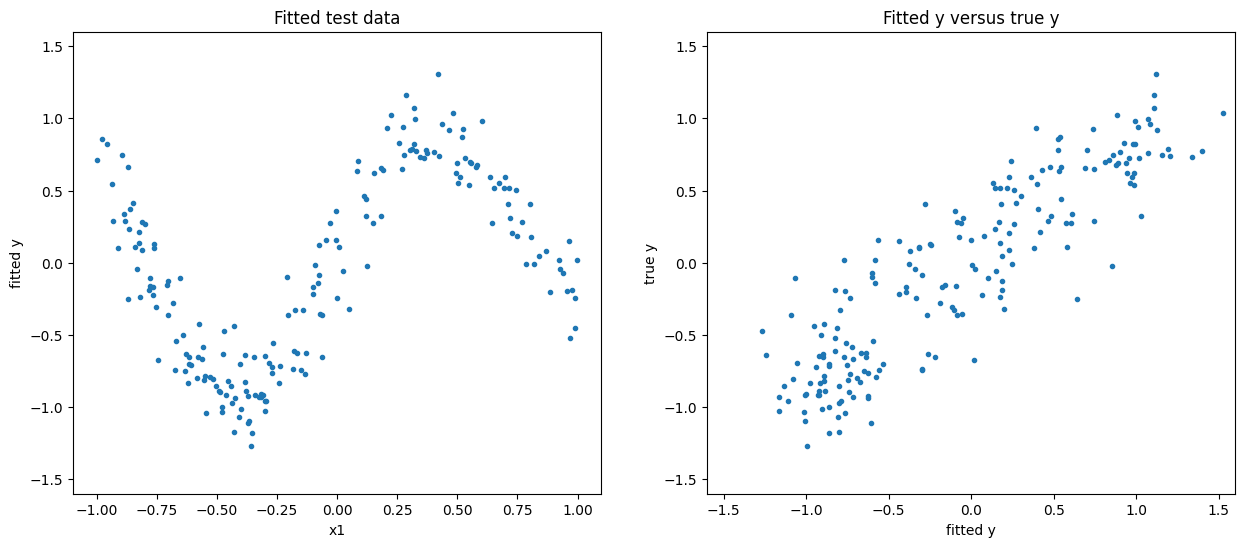

In [36]:
#@title Visualization of fitted value on test data
plt.rcParams['figure.figsize'] = [15, 6]

plt.subplot(1, 2, 1)
plt.plot(x1_test, y_test_hat, '.')
plt.ylim(-1.6, 1.6)
plt.xlabel("x1")
plt.ylabel("fitted y")
plt.title("Fitted test data")

plt.subplot(1, 2, 2)
plt.plot(y_test, y_test_hat, '.')
plt.xlim(-1.6, 1.6)
plt.ylim(-1.6, 1.6)
plt.xlabel("fitted y")
plt.ylabel("true y")
plt.title("Fitted y versus true y")

# Image classification with CNN

## Check GPU availability

In [5]:
# check device availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Prepare datasets and data loaders

In [4]:
# define preprocessing transforms for images

# uncomment the first two transforms to introduce data augmentation
transform = transforms.Compose([
    # transforms.ColorJitter(brightness = 0.05, contrast = 0.05),
    # transforms.RandomAffine(degrees = 10, translate = (0.1,0.1), scale = (0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# import MNIST dataset
train_data = datasets.MNIST('../data', train = True, download = True, transform = transform)
test_data = datasets.MNIST('../data', train = False, transform = transform)

# prepare dataset loaders
train_loader = torch.utils.data.DataLoader(train_data, batch_size = 256, shuffle = True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size = 256)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 512kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.53MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]


## Visualize some images

torch.Size([256, 1, 28, 28])


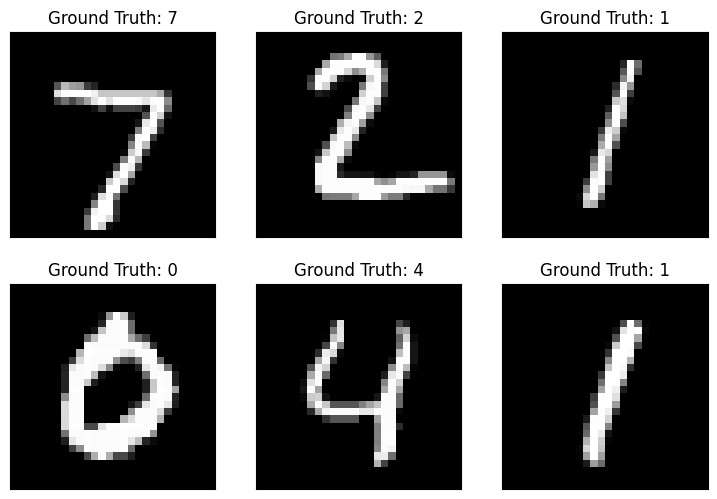

In [6]:
#@title Visualize some digits
examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples)
print(example_data.shape)

plt.rcParams['figure.figsize'] = [9, 6]
fig = plt.figure()
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
  plt.title("Ground Truth: {}".format(example_targets[i]))
  plt.xticks([])
  plt.yticks([])

## Define CNN structure and some utils functions

In [7]:
# our CNN network structure, initialize the CNN model
class myCNN(nn.Module):
    def __init__(self):
        super(myCNN, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, 1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
            nn.Flatten(),
            nn.Linear(9216, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 10),
            nn.LogSoftmax(dim = 1)
        )

    def forward(self, x):
        return self.model(x)

# a utils function for training
def train(model, device, train_loader, optimizer, epoch):
    model.train() # enable dropout
    correct = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        # transfer batches of data to specified device
        data, target = data.to(device), target.to(device)

        # build computation graph
        output = model(data)
        loss = F.nll_loss(output, target)

        # the optimization part
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # count the corrected classified cases
        pred = output.argmax(dim = 1, keepdim = True)  # get the index of the max log-probability
        correct += pred.eq(target.view_as(pred)).sum().item()

    print(f"Epoch {epoch + 1}:", end = "")
    print(f" Training accuracy: {100. * correct / len(train_loader.dataset): .2f} %", end = ";")

# a utils function for evaluation on test dataset
def test(model, device, test_loader):
    model.eval() # disable dropout
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)

    print(' Testing accuracy: {}/{} ({:.0f}%)'.format(
        correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))


## Train CNN

In [8]:
device

device(type='cuda')

In [9]:
# the training
model = myCNN() # initialize our model
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr = 0.005)

nepochs = 10
for epoch in range(nepochs):
  train(model, device, train_loader, optimizer, epoch)
  test(model, device, test_loader)

Epoch 1: Training accuracy:  94.33 %; Testing accuracy: 9869/10000 (99%)
Epoch 2: Training accuracy:  98.10 %; Testing accuracy: 9861/10000 (99%)
Epoch 3: Training accuracy:  98.53 %; Testing accuracy: 9897/10000 (99%)
Epoch 4: Training accuracy:  98.64 %; Testing accuracy: 9902/10000 (99%)
Epoch 5: Training accuracy:  98.83 %; Testing accuracy: 9890/10000 (99%)
Epoch 6: Training accuracy:  98.94 %; Testing accuracy: 9903/10000 (99%)
Epoch 7: Training accuracy:  98.98 %; Testing accuracy: 9896/10000 (99%)
Epoch 8: Training accuracy:  99.17 %; Testing accuracy: 9906/10000 (99%)
Epoch 9: Training accuracy:  99.12 %; Testing accuracy: 9890/10000 (99%)
Epoch 10: Training accuracy:  99.27 %; Testing accuracy: 9900/10000 (99%)


## Evaluate CNN on digit images (written and taken from iPad, not from MNIST test dataset)

MAKE SURE you have already downloaded the `test.pkl` file from https://github.com/shakayoyo/Pytorch_intro/. Also, MAKE SURE you have uploaded it in Colab's current working directory.

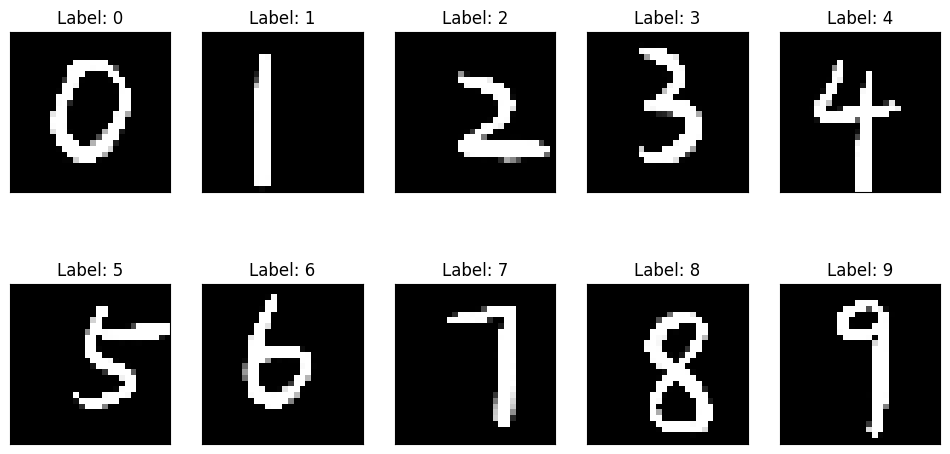

In [13]:
#@title Visualization of self-written digits

import pickle
testdata = pickle.load(open("test.pkl", "rb"))

# digit images (written by myself and taken from my iPad)
# (cont.) will be served as an additional test dataset to evaluate the CNN
plt.rcParams['figure.figsize'] = [12, 6]
for i in range(10):
  plt.subplot(2,5,i + 1)
  plt.imshow(testdata[i][0][0], cmap='gray', interpolation='none')
  plt.title("Label: {}".format(testdata[i][1].item()))
  plt.xticks([])
  plt.yticks([])

In [14]:
# prepare dataset and dataloader for this test dataset
class myMNIST(Dataset):
    def __init__(self, dataset):
      self.sample_size = len(dataset)
      self.dataset = dataset

    def __len__(self):
        return self.sample_size

    def __getitem__(self, idx):
        return self.dataset[idx][0], self.dataset[idx][1]

mytestdataset = myMNIST(testdata)
mytestloader = DataLoader(mytestdataset, batch_size = 10)

# prediction
with torch.no_grad():
  data, target = next(iter(mytestloader))
  data, target = data.to(device), target.to(device)
  output = model(data)
  pred = output.argmax(dim=1, keepdim = True)  # get the index of the max log-probability

Test accuracy on my own test images: 0.8


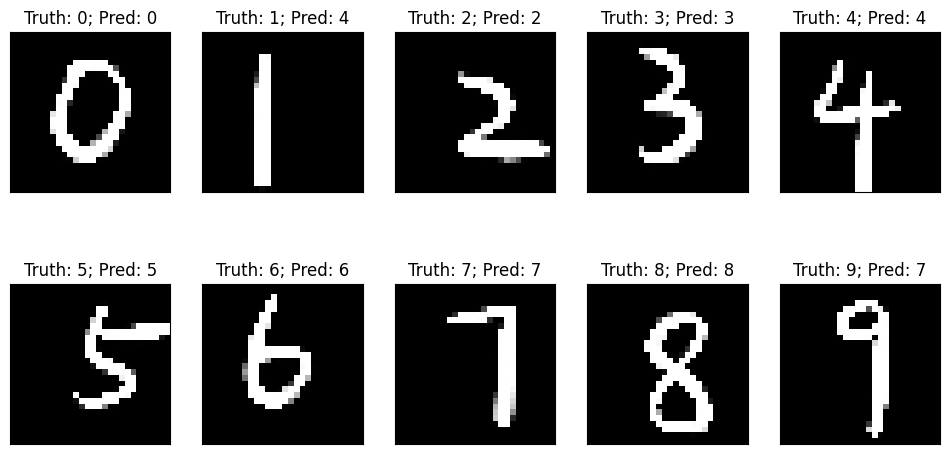

In [15]:
#@title Visualize the prediction result
plt.rcParams['figure.figsize'] = [12, 6]
for i in range(10):
  plt.subplot(2,5,i + 1)
  plt.imshow(testdata[i][0][0], cmap='gray', interpolation='none')
  plt.title("Truth: {}; Pred: {}".format(testdata[i][1].item(), pred[i][0]))
  plt.xticks([])
  plt.yticks([])

print(f"Test accuracy on my own test images: {pred.eq(target.view_as(pred)).sum().item() / 10}")

## Model summary using pytorch-model-summary

In [16]:
# model summary
! pip install pytorch-model-summary
from pytorch_model_summary import summary
print(summary(model.cpu(), torch.zeros((1, 1, 28, 28)), show_input=True))

-----------------------------------------------------------------------
      Layer (type)         Input Shape         Param #     Tr. Param #
          Conv2d-1      [1, 1, 28, 28]             320             320
            ReLU-2     [1, 32, 26, 26]               0               0
          Conv2d-3     [1, 32, 26, 26]          18,496          18,496
            ReLU-4     [1, 64, 24, 24]               0               0
       MaxPool2d-5     [1, 64, 24, 24]               0               0
         Dropout-6     [1, 64, 12, 12]               0               0
         Flatten-7     [1, 64, 12, 12]               0               0
          Linear-8           [1, 9216]       1,179,776       1,179,776
            ReLU-9            [1, 128]               0               0
        Dropout-10            [1, 128]               0               0
         Linear-11            [1, 128]           1,290           1,290
     LogSoftmax-12             [1, 10]               0               0
Total

## Save models

### The state dictionary method

In [17]:
# save parameter values
torch.save(model.state_dict(), "model_dict.pt")

# When one wants to use saved model next time:
# 1. initialize the same CNN model
model_new = myCNN()
# 2. load parameter values
model_new.load_state_dict(torch.load("model_dict.pt"))
model_new.eval()

myCNN(
  (model): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Dropout(p=0.25, inplace=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=9216, out_features=128, bias=True)
    (8): ReLU()
    (9): Dropout(p=0.25, inplace=False)
    (10): Linear(in_features=128, out_features=10, bias=True)
    (11): LogSoftmax(dim=1)
  )
)

### The checkpoint method

In [18]:
# save checkpoint for resuming training
torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict()
            }, "model_checkpoint.pt")

# When one wants to use saved model next time:
# 1. initialize class and optimizer
model_new = myCNN()
optimizer_new = optim.Adam(model_new.parameters(), lr = 0.005)
# 2. load checkpoints for both model and optimizer
checkpoint = torch.load("model_checkpoint.pt")
model_new.load_state_dict(checkpoint['model_state_dict'])
optimizer_new.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
# 3. do whatever you like :)
# - either - evaluate the mode and do some inference
model_new.eval()
# - or - resume training from your last checkpoint
model_new.train()

myCNN(
  (model): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Dropout(p=0.25, inplace=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=9216, out_features=128, bias=True)
    (8): ReLU()
    (9): Dropout(p=0.25, inplace=False)
    (10): Linear(in_features=128, out_features=10, bias=True)
    (11): LogSoftmax(dim=1)
  )
)

In [19]:
print(optimizer.state_dict()['param_groups'][0].keys())
print(optimizer.state_dict()['state'][0].keys())

dict_keys(['lr', 'betas', 'eps', 'weight_decay', 'amsgrad', 'maximize', 'foreach', 'capturable', 'differentiable', 'fused', 'decoupled_weight_decay', 'params'])
dict_keys(['step', 'exp_avg', 'exp_avg_sq'])
